# Triadic Delegation Word Cloud Visualization
This notebook creates a 3-panel word cloud figure showing reasons from three different manager states:
- **(a) Appreciation-state managers** - Reasons for accepting AI recommendations
- **(b) Neutral-state managers** - Reasons for uncertain positions
- **(c) Aversion-state managers** - Reasons for rejecting AI recommendations

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Set up paths
PROJECT_ROOT = Path('.').resolve()
OUTPUT_DIR = PROJECT_ROOT / "Artefacts" / "Analysis_v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3


In [13]:
# Import wordcloud library
from wordcloud import WordCloud
import numpy as np

# Define colors
TEAL = "#0E868B"
PURPLE = "#4A237D"
GREEN = "#3DAB2C"
BLUE = "#1F5496"
YELLOW = "#E8BE00"
WHITE = "#FFFFFF"
BLACK = "#000000"

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Prepare word frequency data for word clouds - 3 manager states
# Format: (word, frequency) for organic cloud layout

WORD_DATA = {
    "Appreciation": {
        "Seems okay but I should check": 85,
        "I still want final say": 88,
        "AI helps but not blindly": 80,
        "Looks useful but situation changed": 78,
        "I know the local issue better": 82,
        "Need to check with the team": 75,
        "Let me confirm first": 72,
        "Maybe later not now": 70,
        "Customer request changed": 76,
        "I don't want to rush this": 79,
        "Need to see the latest update": 74,
        "It depends on the plant situation": 77,
        "I trust it but with caution": 81,
        "Something feels missing": 68,
        "Better to be careful today": 73,
    },
    "Neutral": {
        "Not sure yet": 82,
        "Need more context": 78,
        "I need to think about it": 80,
        "Let's wait and see": 75,
        "Could be right could be wrong": 77,
        "I don't have enough information": 79,
        "Need another opinion": 73,
        "Need to ask someone first": 76,
        "I want to compare options": 74,
        "Maybe approve later": 72,
        "Looks unclear to me": 71,
        "I need more details": 78,
        "Hard to judge now": 70,
        "Not enough confidence": 75,
        "Let's double-check the numbers": 77,
        "I don't fully get the reason": 76,
        "Need to understand the logic": 74,
        "Could work but unsure": 73,
    },
    "Aversion": {
        "I don't trust this": 90,
        "Too risky for me": 88,
        "I prefer doing it myself": 85,
        "AI doesn't know reality": 87,
        "I've seen this fail before": 83,
        "Better safe than sorry": 84,
        "This could cause trouble": 82,
        "I don't want to be responsible": 86,
        "Not worth the risk": 81,
        "I don't believe the output": 85,
        "Human judgment is better": 84,
        "The system misses too much": 82,
        "I don't want surprises": 80,
        "This feels wrong": 79,
        "I won't approve this": 89,
        "AI is guessing again": 81,
        "I know better than the model": 83,
        "If it fails we pay the price": 86,
    }
}

print(f"Word data loaded for {len(WORD_DATA)} manager states")

Word data loaded for 2 manager types


In [ ]:
def color_func_appreciation(word, font_size, position, orientation, random_state=None, **kwargs):
    """Generate varied colors for appreciation manager words"""
    colors = [GREEN, TEAL, BLUE]
    return np.random.choice(colors)

def color_func_neutral(word, font_size, position, orientation, random_state=None, **kwargs):
    """Generate varied colors for neutral manager words"""
    colors = [TEAL, BLUE, PURPLE]
    return np.random.choice(colors)

def color_func_aversion(word, font_size, position, orientation, random_state=None, **kwargs):
    """Generate varied colors for aversion manager words"""
    colors = [PURPLE, BLUE, YELLOW]
    return np.random.choice(colors)

def create_wordcloud_figure():
    """Create a 3-panel word cloud figure for manager states."""
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 9))
    fig.patch.set_facecolor(WHITE)
    
    manager_types = ["Appreciation", "Neutral", "Aversion"]
    titles = [
        "(a) Reasons from Appreciation-state managers",
        "(b) Reasons from Neutral-state managers",
        "(c) Reasons from Aversion-state managers",
    ]
    color_funcs = [color_func_appreciation, color_func_neutral, color_func_aversion]
    
    for ax, mgr_type, title, color_func in zip(axes, manager_types, titles, color_funcs):
        # Create word cloud with optimized parameters
        wordcloud = WordCloud(
            width=900,
            height=700,
            background_color=WHITE,
            colormap=None,
            relative_scaling=0.6,
            min_font_size=12,
            max_font_size=150,
            prefer_horizontal=0.6,
            max_words=80,
            collocations=False,
            random_state=42,
            margin=10,
        ).generate_from_frequencies(WORD_DATA[mgr_type])
        
        # Apply custom color function
        wordcloud.recolor(color_func=color_func)
        
        # Display on axes
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        
        # Add title
        ax.text(0.5, 1.02, title, transform=ax.transAxes,
                ha='center', va='bottom', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    output_path = OUTPUT_DIR / "triadic_wordcloud_figure.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor=WHITE, pad_inches=0.3)
    print(f"Figure saved to: {output_path}")
    
    return fig, output_path

print("Word cloud generation function defined successfully")

Word cloud generation function defined successfully


Figure saved to: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\triadic_wordcloud_figure.png

Word cloud figure created successfully!
Output: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\triadic_wordcloud_figure.png


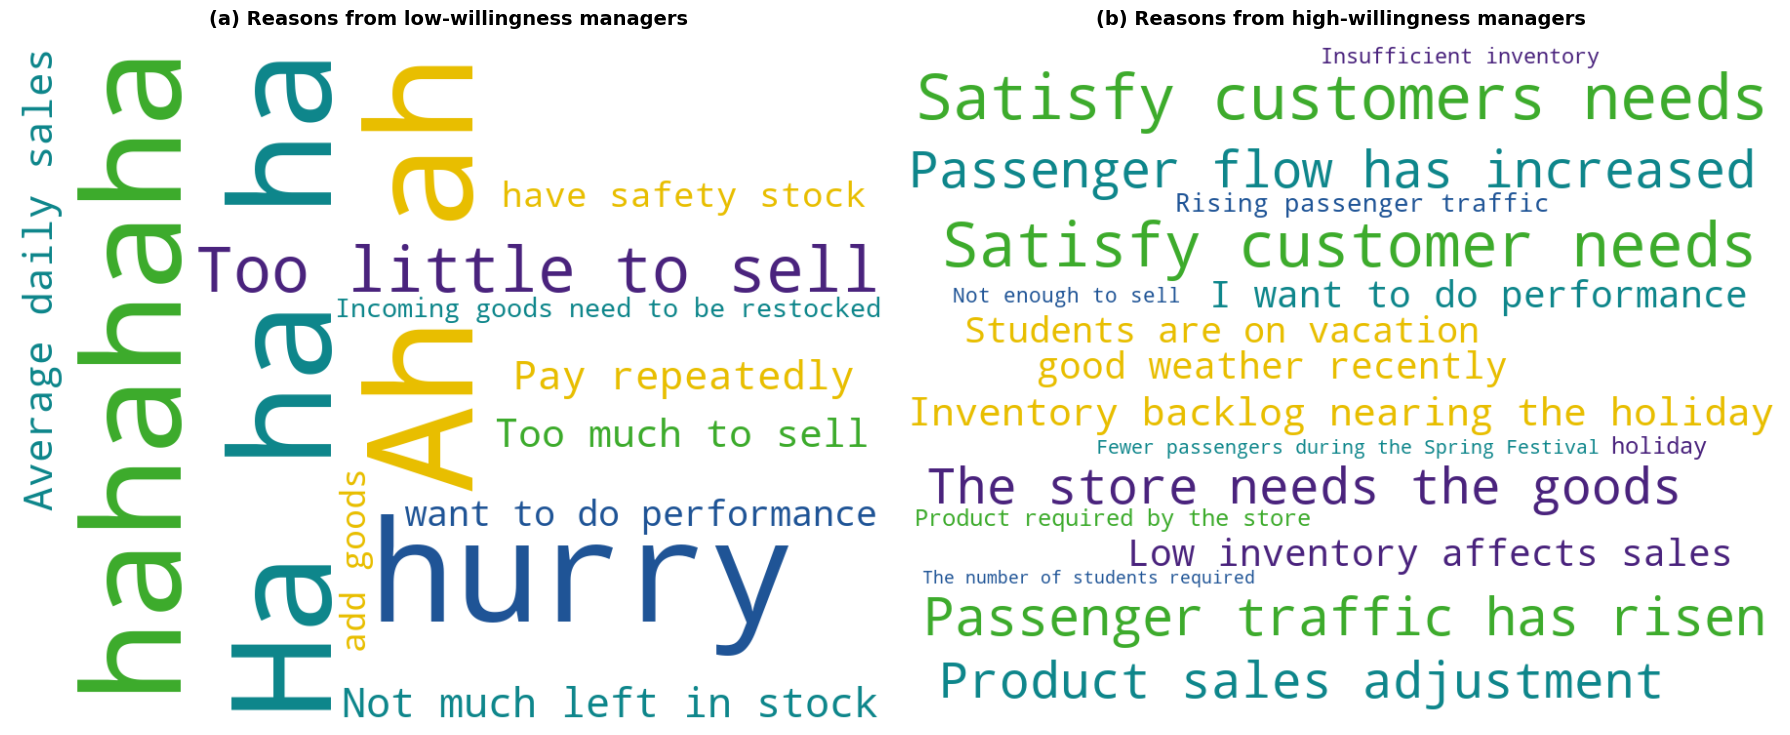

In [25]:
# Generate the word cloud figure
fig, output_path = create_wordcloud_figure()
print(f"\nWord cloud figure created successfully!")
print(f"Output: {output_path}")

In [17]:
# Display the figure
plt.show()